# Multiclass Image Classification on Fashion-MNIST using a Multi-Layer Perceptron (MLP)

In [18]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense , Flatten

In [2]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full , y_train_full) , (X_test , y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
X_train_full.shape

(60000, 28, 28)

In [4]:
y_train_full.shape

(60000,)

In [5]:
X_test.shape

(10000, 28, 28)

In [6]:
y_test.shape

(10000,)

In [13]:
X_train_full[5]

array([[  0,   0,   0,   0,   1,   0,   0,   0,   0,  22,  88, 188, 172,
        132, 125, 141, 199, 143,   9,   0,   0,   0,   1,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,   0,  20, 131, 199, 206, 196, 202, 242,
        255, 255, 250, 222, 197, 206, 188, 126,  17,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,  35, 214, 191, 183, 178, 175, 168, 150,
        162, 159, 152, 158, 179, 183, 189, 195, 185,  82,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 170, 190, 172, 177, 176, 171, 169, 162,
        155, 148, 154, 169, 174, 175, 175, 177, 183, 188,  12,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  25, 194, 180, 178, 174, 184, 187, 189, 187,
        184, 181, 189, 200, 197, 193, 190, 178, 175, 194,  90,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  42, 218, 191, 197, 208, 204, 211, 209, 210,
        212, 211, 214, 215, 213, 214, 211, 211, 191, 200, 158,   0,   0,
          0,   0],
       [  

In [14]:
y_train_full[5]

np.uint8(2)

In [15]:
# Note that the dataset is already split into a training set and a test set, but there is no
# validation set, so let’s create one. Moreover, since we are going to train the neural net
# work using Gradient Descent, we must scale the input features. For simplicity, we just
# scale the pixel intensities down to the 0-1 range by dividing them by 255.0 (this also
# converts them to floats):
X_valid , X_train = X_train_full[:5000] / 255.0 , X_train_full[5000:] / 255.0
y_valid , y_train = y_train_full[:5000] , y_train_full[5000:]

In [20]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
model = Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(300 , activation='relu'))
model.add(Dense(100 , activation ='relu'))
model.add(Dense(10 , activation='softmax'))

D:\JUPYTER NOTEBOOK\DEEP LEARNING\dl_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.layers

[<Flatten name=flatten_1, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [23]:
model.layers[1].name

'dense'

In [30]:
# Compiling the model
model.compile(loss = 'sparse_categorical_crossentropy' , optimizer='sgd' , metrics=['accuracy'])
history = model.fit(X_train , y_train , epochs = 30 , validation_data = (X_valid , y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7688 - loss: 0.7130 - val_accuracy: 0.8174 - val_loss: 0.5291
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8299 - loss: 0.4862 - val_accuracy: 0.8448 - val_loss: 0.4504
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8468 - loss: 0.4430 - val_accuracy: 0.8326 - val_loss: 0.4633
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8541 - loss: 0.4162 - val_accuracy: 0.8636 - val_loss: 0.4014
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8615 - loss: 0.3954 - val_accuracy: 0.8570 - val_loss: 0.4027
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8670 - loss: 0.3789 - val_accuracy: 0.8658 - val_loss: 0.3848
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8703 - loss: 0.3658 - val_accuracy: 0.8770 - val_loss: 0.3601
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8760 - loss: 0.3528 - 

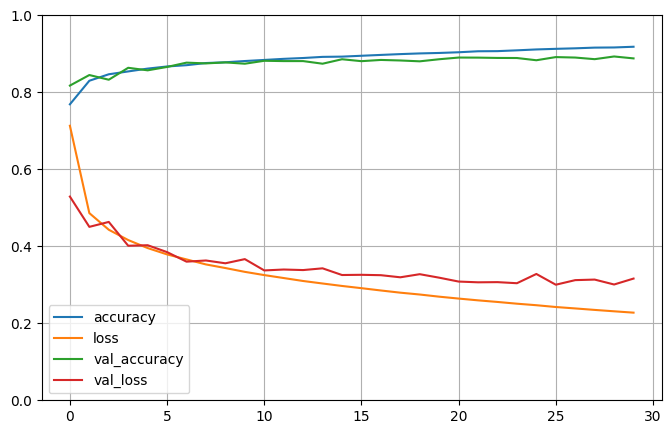

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1) # set the vertival range to [0-1]
plt.show()

In [34]:
# Prediction
X_new = X_test[:3]

In [35]:
y_proba = model.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


In [36]:
y_proba.round(2)

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

As you can see, for each instance the model estimates one probability per class, from
class 0 to class 9. F

As you can see, for each instance the model estimates one probability per class, from
class 0 to class 9. For example, for the first image it estimates that the probability of
class 9 (ankle boot) is 79%, the probability of class 7 (sneaker) is 12%, the probability
of class 5 (sandal) is 9%, and the other classes are negligible. In other words, it
“believes” it’s footwear, probably ankle boots, but it’s not entirely sure, it might be
sneakers or sandals instead. If you only care about the class with the highest estima
ted probability (even if that probability is quite low) then you can use the pre
dict_classes() method instead:

In [57]:
import numpy as np
y_proba = model.predict(X_test) # Probabilties
y_pred = np.argmax(y_proba , axis = 1)  # Class index

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [58]:
print(y_proba.shape)

(10000, 10)


In [59]:
print(y_test.shape)
print(y_pred.shape)

(10000,)
(10000,)


In [60]:
y_pred

array([9, 2, 1, ..., 8, 1, 5], shape=(10000,))

In [61]:
from sklearn.metrics import accuracy_score


In [62]:
accuracy_score(y_test , y_pred)

0.8422